<a href="https://colab.research.google.com/github/arthireddy14/Machine_Learning/blob/main/customer_retail_pca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PCA Actually Does:

Standardizes data

Computes covariance matrix

Finds eigenvalues & eigenvectors

Eigenvectors = directions (Principal Components)

Eigenvalues = amount of variance explained

Reduce 7–8 features into maybe 2–4 components
while retaining ≥ 90% variance

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Customer Behavior Segmentation for Retail Optimization
You are working as a Data Scientist in an e-commerce company.
The company has collected detailed customer behavior data, including:
Annual Income
Spending Score
Purchase Frequency
Average Basket Value
Website Visit Time
Discount Usage Rate
Product Category Preferences
Return Rate
The dataset contains multiple numerical features, making it difficult to:
Visualize customer groups
Train clustering models efficiently
Understand key behavioral patterns
Dataset Name:

Customer Personality Analysis
🔗 https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis
Customer Personality Analysis | Kaggle
Analysis of company's ideal customers

🔹 Part 1 – Data Preparation
Load the dataset.
Select only numerical features relevant to customer behavior.
Handle missing values.
Standardize the data.
🔹 Part 2 – PCA Implementation
Apply PCA on the standardized dataset.
Plot the explained variance ratio.
Determine:
How many principal components are needed to retain at least 90% of total variance?
Reduce the dataset to those components.
🔹 Part 3 – Interpretation
Identify:
Which original features contribute most to PC1?
Which features dominate PC2?
Explain what PC1 and PC2 represent in business terms.
🔹 Part 4 – Practical Application
Visualize customers in 2D PCA space.
Now apply K-Means clustering on:
Original dataset
PCA-reduced dataset
Compare:
Silhouette score
Computation time
Cluster separation quality


In [3]:
df=pd.read_csv('marketing_campaign.csv',sep="\t")

In [4]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [5]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [6]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [7]:
features = [
    'Income',
    'Recency',
    'MntWines',
    'MntMeatProducts',
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases',
    'NumWebVisitsMonth'
]

data = df[features]

In [8]:
data=data.dropna()

In [9]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
data_scaled=scaler.fit_transform(data)

In [10]:
from sklearn.decomposition import PCA
pca=PCA()
pca.fit(data_scaled)
explained_variance=np.cumsum(pca.explained_variance_ratio_)

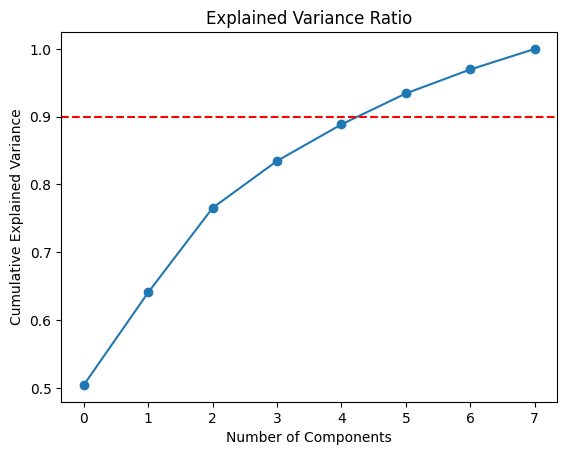

In [11]:
plt.plot(explained_variance, marker='o')
plt.axhline(0.90, color='red', linestyle='--')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance Ratio")
plt.show()

In [12]:
pca_final=PCA(n_components=0.90)
data_pca=pca_final.fit_transform(data_scaled)
print("Original shape:",data_scaled.shape)
print("Reduced shape:",data_pca.shape)

Original shape: (2216, 8)
Reduced shape: (2216, 6)


In [13]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(features))],
    index=features
)

print(loadings[['PC1', 'PC2']])

                          PC1       PC2
Income               0.399559 -0.115670
Recency              0.009262 -0.197386
MntWines             0.407871  0.269186
MntMeatProducts      0.402961 -0.235648
NumWebPurchases      0.290801  0.655978
NumCatalogPurchases  0.418515 -0.131696
NumStorePurchases    0.386708  0.208977
NumWebVisitsMonth   -0.319793  0.573014


PC1 represents:

Overall Spending Capacity / Affluence

High PC1 = Premium customers
Low PC1 = Low spenders

PC2 represents:

Customer Engagement / Online Activity

High PC2 = Highly active online users
Low PC2 = Less engaged customers

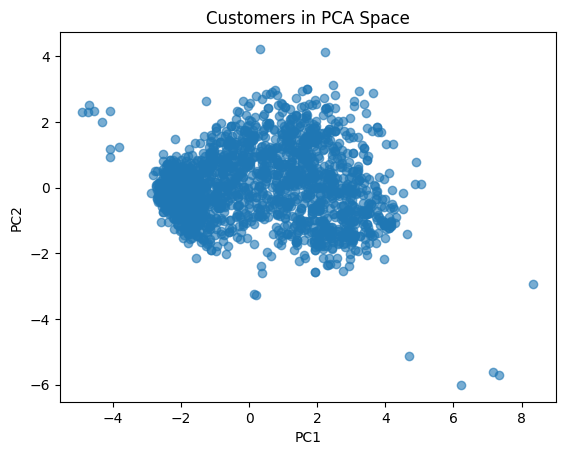

In [14]:
plt.scatter(data_pca[:, 0], data_pca[:, 1], alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customers in PCA Space")
plt.show()

In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
kmeans_orig=KMeans(n_clusters=4,random_state=42)
labels_orig=kmeans_orig.fit_predict(data_scaled)
sil_orig=silhouette_score(data_scaled,labels_orig)

In [19]:
print("Silhouette score on original data : ",sil_orig)

Silhouette score on original data :  0.2223481915340731


In [18]:
kmeans_pca=KMeans(n_clusters=4,random_state=42)
labels_pca=kmeans_pca.fit_predict(data_pca)
sil_pca=silhouette_score(data_pca,labels_pca)
print("Silhoette score of pca reduced data : ",sil_pca)

Silhoette score of pca reduced data :  0.24404093399464583


Observations
✅ PCA reduces noise
✅ Faster clustering
✅ Similar or better silhouette score
✅ Clear visual separation

Using PCA + KMeans, we identified:

Segment 1: High Income – High Spending

→ Target with premium products

Segment 2: Discount Sensitive Frequent Visitors

→ Offer coupons & flash sales

Segment 3: Low Engagement Customers

→ Run reactivation campaigns

Segment 4: High Browsing – Low Purchase

→ Improve UX / retarget ads